<a href="https://maestriasydiplomados.tec.mx/posgrados/maestria-en-inteligencia-artificial-aplicada"><img src="logo_MR4010.png"></a>
<h1> <div align="center"> Dr. David Antonio-Torres</div> </h1>

# Ejercicio: Predecir el precio de casas en EE.UU. con Regresión Lineal Múltiple

En este ejercicio usamos **Regresión Lineal Múltiple** para predecir el precio de venta de una casa basándonos en varias características de la zona donde está: el ingreso promedio de los vecinos, la antigüedad de las casas, el número de habitaciones, la población del área, etc.

**Dataset:** USA Housing — 5,000 registros de ventas de casas en diferentes ciudades de EE.UU.
Fuente: https://www.kaggle.com/datasets/gopalchettri/usa-housing

**¿Qué diferencia hay con el ejercicio anterior?** En el ejercicio anterior usábamos una sola variable para predecir (irregularidad → velocidad). Ahora usamos **múltiples variables al mismo tiempo** — eso hace el modelo mucho más realista, porque en la práctica el precio de una casa depende de muchos factores juntos, no de uno solo.

## Paso 1: Cargar las herramientas necesarias

Importamos tres librerías fundamentales:
- **pandas**: para cargar y manejar tablas de datos (como Excel pero dentro de Python)
- **numpy**: para hacer cálculos matemáticos con listas de números de forma eficiente
- **matplotlib**: para crear gráficas y visualizaciones

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Paso 2: Cargar el archivo de datos y explorar su estructura

Cargamos el archivo CSV con los 5,000 registros de casas. Las primeras celdas nos muestran cómo están organizados los datos: cuántas columnas tiene, qué tipo de información guarda cada una, y cómo lucen los primeros registros.

Esta exploración inicial es siempre el primer paso antes de construir cualquier modelo — necesitamos entender los datos antes de usarlos.

In [16]:
USAhousing = pd.read_csv('USA_Housing.csv')

In [17]:
USAhousing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [18]:
USAhousing.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 499.6 KB


In [19]:
USAhousing.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [20]:
USAhousing.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address'],
      dtype='str')

## Paso 3: Verificar la calidad de los datos (¿faltan valores?)

Antes de entrenar cualquier modelo, revisamos que no haya datos faltantes. Un modelo entrenado con datos incompletos puede aprender cosas incorrectas y dar predicciones poco confiables.

Si alguna columna tuviera celdas vacías (llamadas "NaN" = Not a Number), tendríamos que decidir si rellenarlas con algún valor estimado o eliminar esas filas antes de continuar. En este dataset, felizmente todos los datos están completos.

In [21]:
print(USAhousing.isnull().sum())

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


## Paso 4: Descubrir qué variables influyen más en el precio

La **correlación** es una medida de qué tan relacionadas están dos columnas:
- Valor cercano a **+1**: cuando una sube, la otra también sube (relación positiva)
- Valor cercano a **-1**: cuando una sube, la otra baja (relación inversa)
- Valor cercano a **0**: no hay relación entre las dos columnas

Aquí vemos qué características del área tienen más influencia sobre el precio de la casa. Esto nos ayuda a entender el modelo antes de construirlo — ¿qué factores importan más?

In [22]:
corr = USAhousing.corr(numeric_only=True)
print(corr)

                              Avg. Area Income  Avg. Area House Age  \
Avg. Area Income                      1.000000            -0.002007   
Avg. Area House Age                  -0.002007             1.000000   
Avg. Area Number of Rooms            -0.011032            -0.009428   
Avg. Area Number of Bedrooms          0.019788             0.006149   
Area Population                      -0.016234            -0.018743   
Price                                 0.639734             0.452543   

                              Avg. Area Number of Rooms  \
Avg. Area Income                              -0.011032   
Avg. Area House Age                           -0.009428   
Avg. Area Number of Rooms                      1.000000   
Avg. Area Number of Bedrooms                   0.462695   
Area Population                                0.002040   
Price                                          0.335664   

                              Avg. Area Number of Bedrooms  Area Population  \
Avg. Area

## Paso 5: Separar los datos de entrada de la variable a predecir

Le indicamos al modelo qué columnas son los datos de entrada (X = las características de la zona) y cuál es la variable que queremos que aprenda a predecir (y = el precio de la casa).

Siempre excluimos la columna de dirección porque es texto — el modelo solo puede trabajar con números.

In [23]:
X = USAhousing[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms','Avg. Area Number of Bedrooms', 'Area Population']]
y = USAhousing['Price']

## Paso 6: Dividir los datos en entrenamiento (70%) y prueba (30%)

Dividimos los 5,000 registros en dos grupos:
- **3,500 casas para entrenar**: el modelo las estudia con sus precios reales y aprende los patrones
- **1,500 casas para probar**: el modelo predice el precio de estas casas sin haberlas visto nunca

Esta separación es esencial para saber si el modelo **realmente aprendió** a generalizar, o si simplemente memorizó los datos de entrenamiento. Es como preparar un examen: el estudiante estudia unos temas (entrenamiento) y luego es evaluado con preguntas nuevas (prueba).

El parámetro `random_state=42` asegura que siempre se haga la misma división, para que los resultados sean reproducibles.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [25]:
print(X_train.shape)
print(y_train.shape)

(3500, 5)
(3500,)


In [26]:
print(X_test.shape)
print(y_test.shape)

(1500, 5)
(1500,)


## Paso 7: Crear y entrenar el modelo

Aquí el modelo analiza las 3,500 casas de entrenamiento y aprende **qué peso tiene cada variable** en el precio final. Le damos las características y los precios correctos, y el modelo ajusta sus parámetros internos para minimizar el error.

Después del `.fit()`, el modelo tiene listo su "fórmula" para predecir el precio de cualquier casa nueva.

In [27]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Paso 8: Ver qué aprendió el modelo (los coeficientes)

El modelo aprendió un peso o coeficiente para cada variable. Estos números nos dicen cuánto cambia el precio predicho cuando esa variable aumenta en 1 unidad, manteniendo todo lo demás constante.

Por ejemplo: si el coeficiente del ingreso promedio del área es ~21.63, significa que por cada dólar adicional en el ingreso promedio de la zona, el precio estimado de la casa sube $21.63.

El número de intercepción es el precio de base que el modelo asigna cuando todas las variables son cero — en la práctica es solo un ajuste matemático, no tiene interpretación de negocio directa.

In [28]:
print(linear_model.intercept_)

-2638673.4261901686


In [29]:
print(linear_model.coef_)

[2.16257989e+01 1.65590393e+05 1.19827783e+05 2.36109526e+03
 1.52165814e+01]


## Paso 9: Predecir los precios del set de prueba

Le damos al modelo las características de las 1,500 casas de prueba (sin decirle el precio real) y le pedimos que estime cada precio. Luego comparamos las predicciones con los precios reales en una gráfica.

En la gráfica, si los puntos se agrupan a lo largo de una diagonal, significa que el modelo predice bien. Puntos muy alejados de esa diagonal son casos donde el modelo se equivocó más.

In [30]:
predictions = linear_model.predict(X_test)

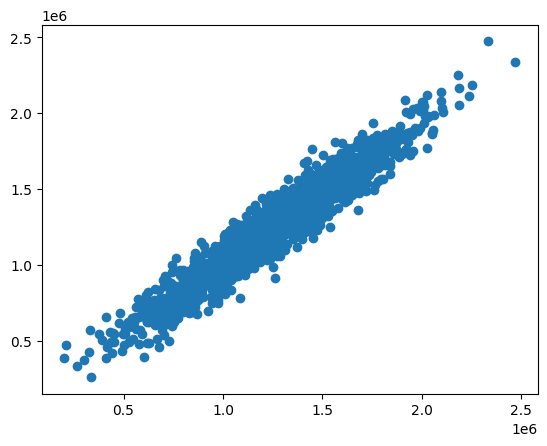

In [31]:
# se comparan las predicciones con las target de prueba
plt.scatter(y_test,predictions)

## Paso 10: Medir la precisión del modelo

Comparamos los precios que predijo el modelo con los precios reales de las 1,500 casas de prueba. Usamos tres métricas de error:

- **MAE** (Error Absoluto Medio): en promedio, ¿en cuántos dólares se equivoca el modelo? (~$81,135)
- **MSE** (Error Cuadrático Medio): similar al MAE pero penaliza más los errores grandes. El resultado está en dólares al cuadrado, por eso es difícil de interpretar solo.
- **RMSE** (Raíz del Error Cuadrático Medio): la métrica más interpretable — el error típico en dólares. Un RMSE de ~$100,342 en casas que cuestan en promedio $1,230,000 representa un error de solo el ~8%, que es un buen resultado.

In [32]:
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 81135.56609336879
MSE: 10068422551.400831
RMSE: 100341.52954485411


# Gracias por la atención